## Load Data 

In [5]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np


df = pd.read_csv('../data/raw/AmesHousing.csv')

df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [4]:
df_copy = df.copy()

select best features for determining how it will affext the house price 

> total actual house area 

- Total_SF = Gr Liv Area + Total Bsmt SF + Garage Area

> total actual house age 

- House_Age = Yr Sold - Year Built

> remodeled house 
- Was_Remodeled = 0 ot 1 in specific year 

In [2]:
print(df[['Gr Liv Area', 'Total Bsmt SF', 'Garage Area', 
          'Lot Area', 'Year Built', 'SalePrice']].describe())

       Gr Liv Area  Total Bsmt SF  Garage Area       Lot Area   Year Built  \
count  2930.000000    2929.000000  2929.000000    2930.000000  2930.000000   
mean   1499.690444    1051.614544   472.819734   10147.921843  1971.356314   
std     505.508887     440.615067   215.046549    7880.017759    30.245361   
min     334.000000       0.000000     0.000000    1300.000000  1872.000000   
25%    1126.000000     793.000000   320.000000    7440.250000  1954.000000   
50%    1442.000000     990.000000   480.000000    9436.500000  1973.000000   
75%    1742.750000    1302.000000   576.000000   11555.250000  2001.000000   
max    5642.000000    6110.000000  1488.000000  215245.000000  2010.000000   

           SalePrice  
count    2930.000000  
mean   180796.060068  
std     79886.692357  
min     12789.000000  
25%    129500.000000  
50%    160000.000000  
75%    213500.000000  
max    755000.000000  


### check houses distributions 

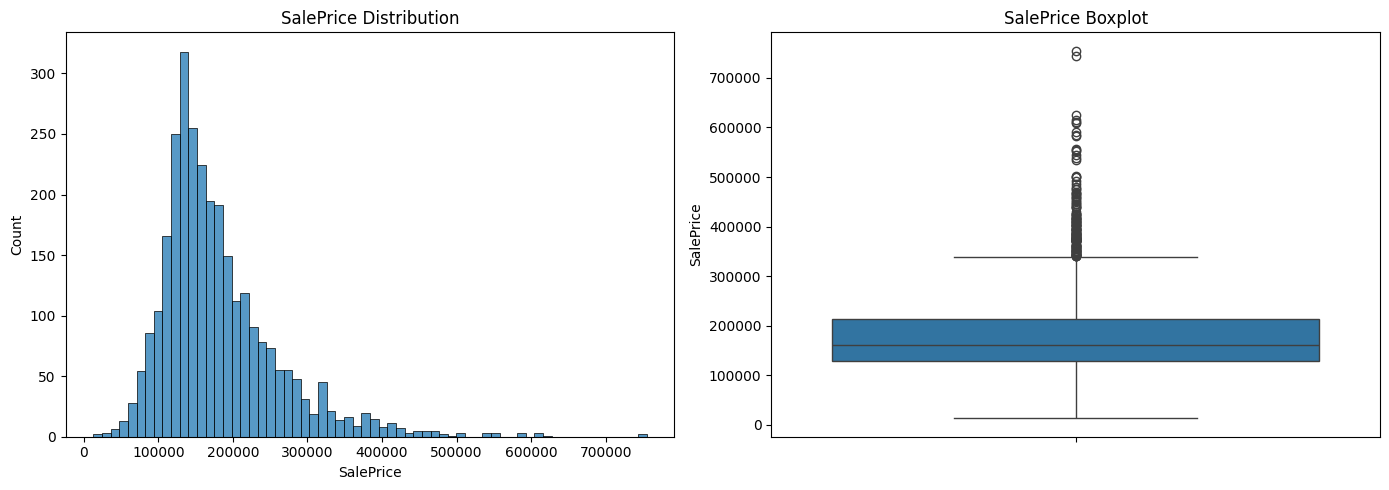

In [3]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['SalePrice'], ax=axes[0])
axes[0].set_title('SalePrice Distribution')

sns.boxplot(df['SalePrice'], ax=axes[1])
axes[1].set_title('SalePrice Boxplot')

plt.tight_layout()
plt.show()

- right skewed 
- over 400k may be outliers 


> apply logg transform to see the results  on ``` df_copy ```

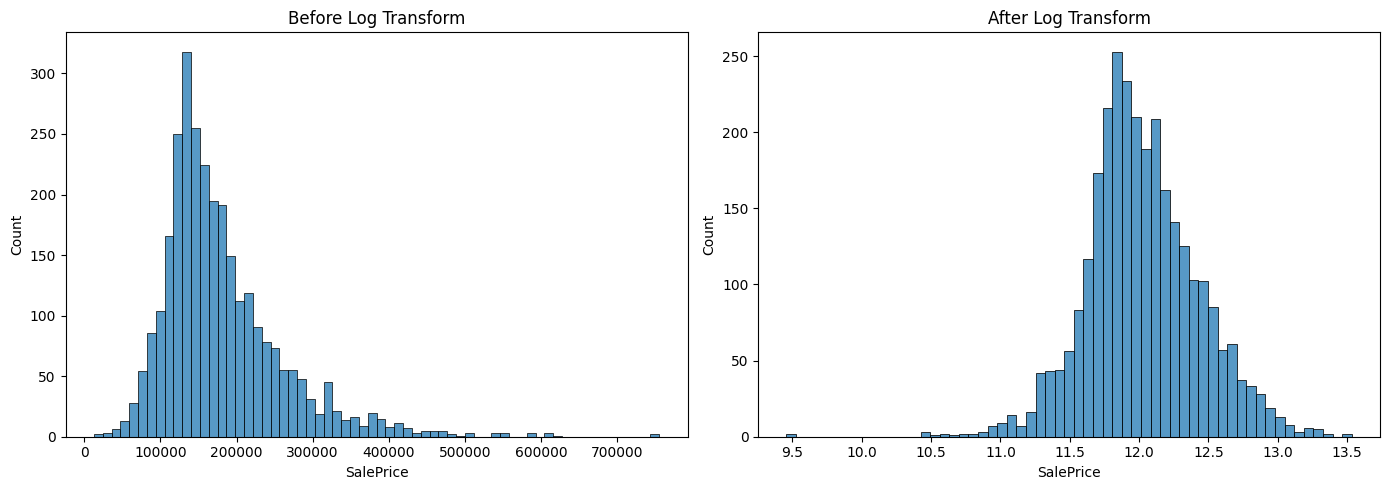

In [6]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_copy['SalePrice'], ax=axes[0])
axes[0].set_title('Before Log Transform')

sns.histplot(np.log1p(df_copy['SalePrice']), ax=axes[1])
axes[1].set_title('After Log Transform')

plt.tight_layout()
plt.show()

Now it is normally distributed !! 

### let's check missing values 

In [7]:
missing = df_copy.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)
print(f"\nTotal columns with missing values: {len(missing)}")

Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Cond        159
Garage Qual        159
Garage Finish      159
Garage Yr Blt      159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Cond           80
Bsmt Qual           80
BsmtFin Type 1      80
Mas Vnr Area        23
Bsmt Half Bath       2
Bsmt Full Bath       2
BsmtFin SF 1         1
Garage Cars          1
Garage Area          1
Total Bsmt SF        1
Bsmt Unf SF          1
BsmtFin SF 2         1
Electrical           1
dtype: int64

Total columns with missing values: 27


looks like ``` POOL QC ``` has 99% missing values 
- we may remove this columns but it will prevent model from learning that it has pool or not so we should label missing values with ``None``